# 🌾 Paddy Yield Prediction — EDA & Machine Learning

**Complete project:** EDA → preprocessing → Decision Tree → Random Forest → SVR → model comparison → save model → prediction test.

The dataset contains agricultural, weather, fertilizer, irrigation and crop-management features.  
The target is **Paddy yield (in Kg)**.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error

In [13]:
import os

os.chdir(r"C:\Users\asus\OneDrive\Desktop\Paddy_Yield_Project")

df = pd.read_csv("paddydataset.csv")

In [14]:

df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (2789, 45)

First 5 Rows:
   Hectares     Agriblock      Variety Soil Types  Seedrate(in Kg)  \
0         6     Cuddalore        CO_43   alluvial              150   
1         6   Kurinjipadi      ponmani       clay              150   
2         6       Panruti  delux ponni   alluvial              150   
3         6  Kallakurichi        CO_43       clay              150   
4         6  Sankarapuram      ponmani   alluvial              150   

   LP_Mainfield(in Tonnes) Nursery  Nursery area (Cents)  \
0                     75.0     dry                   120   
1                     75.0     wet                   120   
2                     75.0     dry                   120   
3                     75.0     wet                   120   
4                     75.0     dry                   120   

   LP_nurseryarea(in Tonnes)  DAP_20days  ...  Wind Direction_D1_D30  \
0                          6         240  ...                     SW   
1                          6     

In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   str    
 2   Variety                             2789 non-null   str    
 3   Soil Types                          2789 non-null   str    
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   str    
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 non-null   fl

In [16]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hectares,2789.0,NaN,NaN,NaN,3.717461,1.437777,1.0,3.0,4.0,5.0,6.0
Agriblock,2789,6,Sankarapuram,605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variety,2789,3,ponmani,1061,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Soil Types,2789,2,clay,1521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seedrate(in Kg),2789.0,NaN,NaN,NaN,92.936536,35.94442,25.0,75.0,100.0,125.0,150.0
LP_Mainfield(in Tonnes),2789.0,NaN,NaN,NaN,46.468268,17.97221,12.5,37.5,50.0,62.5,75.0
Nursery,2789,2,dry,1540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nursery area (Cents),2789.0,NaN,NaN,NaN,74.349229,28.755536,20.0,60.0,80.0,100.0,120.0
LP_nurseryarea(in Tonnes),2789.0,NaN,NaN,NaN,3.717461,1.437777,1.0,3.0,4.0,5.0,6.0
DAP_20days,2789.0,NaN,NaN,NaN,148.698458,57.511072,40.0,120.0,160.0,200.0,240.0


In [17]:
missing = df.isna().sum().sort_values(ascending=False)
print("Total missing values:", missing.sum())
display(missing[missing > 0])


Total missing values: 0


Series([], dtype: int64)

In [18]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Keep the original data for EDA, then remove duplicates for modeling.
df_model = df.drop_duplicates().copy()
print("Shape after removing duplicates:", df_model.shape)


Duplicate rows: 451
Shape after removing duplicates: (2338, 45)


In [25]:
TARGET = "Paddy yield(in Kg)"

In [26]:
cat_cols = df_model.drop(columns=[TARGET]).select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

num_cols = df_model.drop(columns=[TARGET]).select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:", len(cat_cols))
print(cat_cols)
print("\nNumerical features:", len(num_cols))
print(num_cols)


Categorical features: 8
['Agriblock', 'Variety', 'Soil Types', 'Nursery', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 'Wind Direction_D61_D90', 'Wind Direction_D91_D120']

Numerical features: 36
['Hectares', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_

In [ ]:
# Target distribution
plt.figure(figsize=(10,5))
sns.histplot(df_model[TARGET], kde=True)
plt.title("Paddy Yield Distribution")
plt.xlabel("Paddy Yield (Kg)")
plt.show()

display(df_model[TARGET].describe())


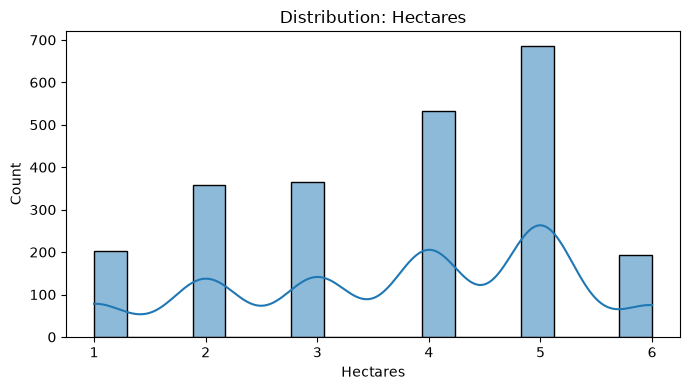

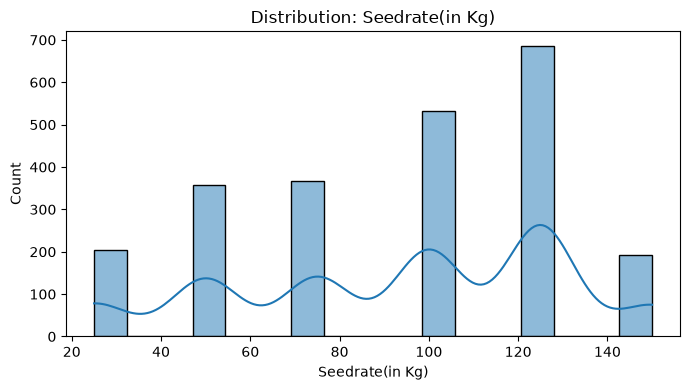

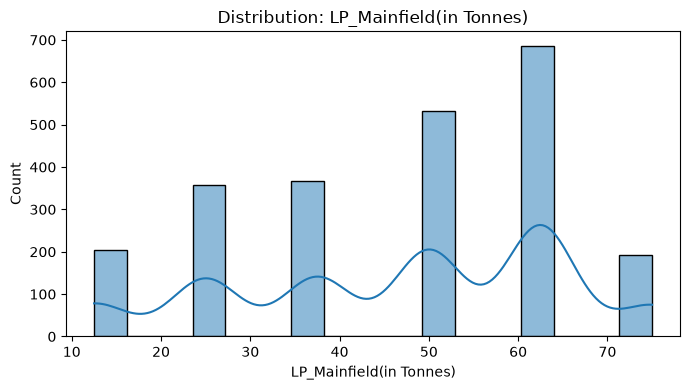

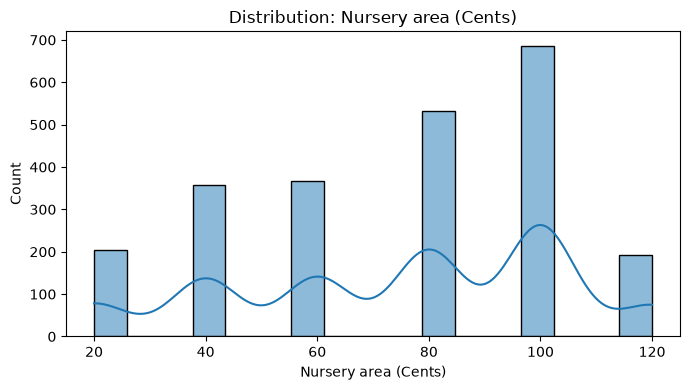

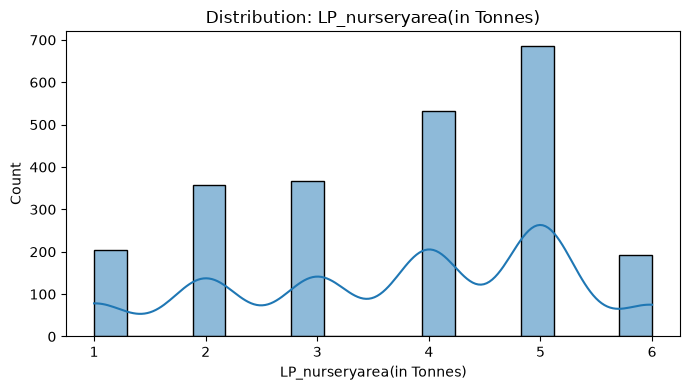

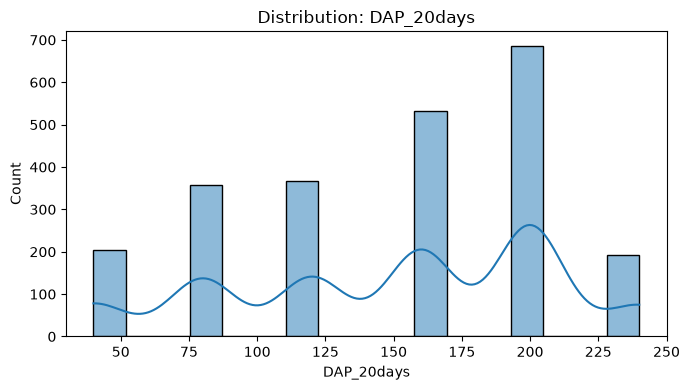

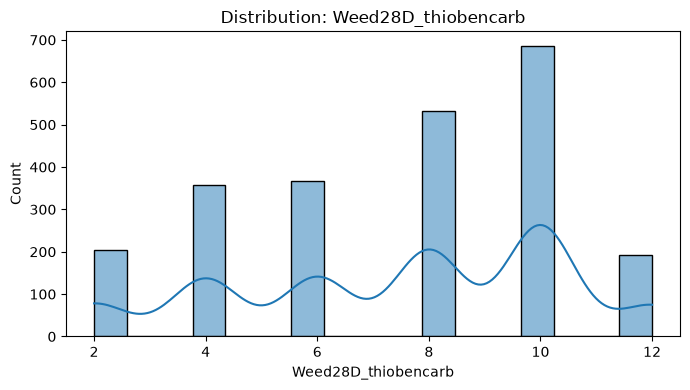

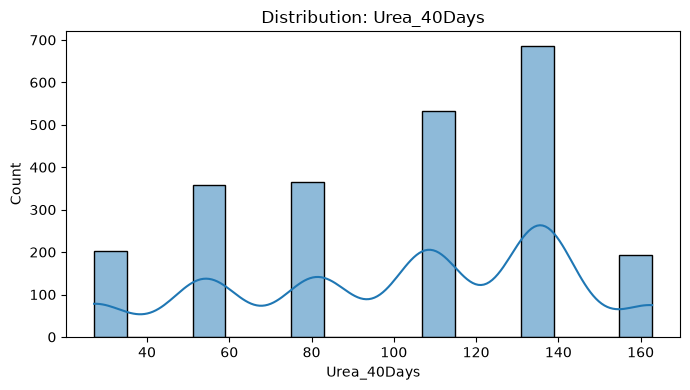

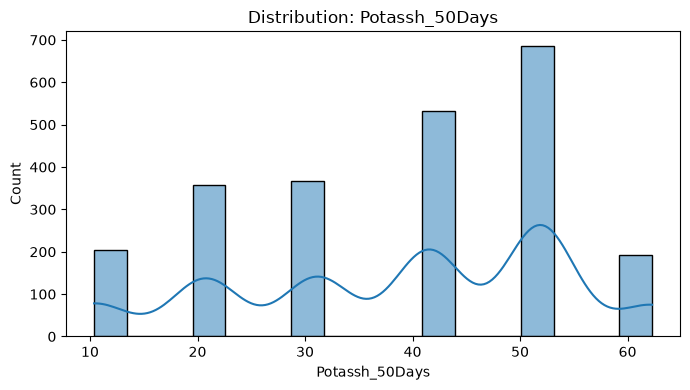

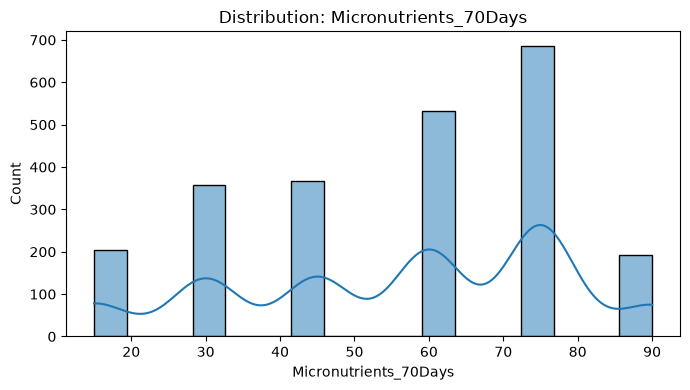

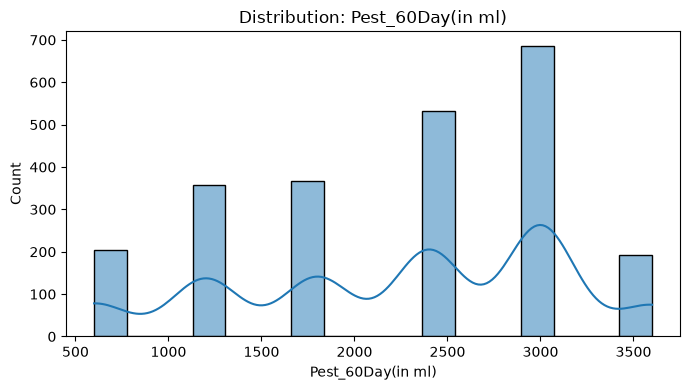

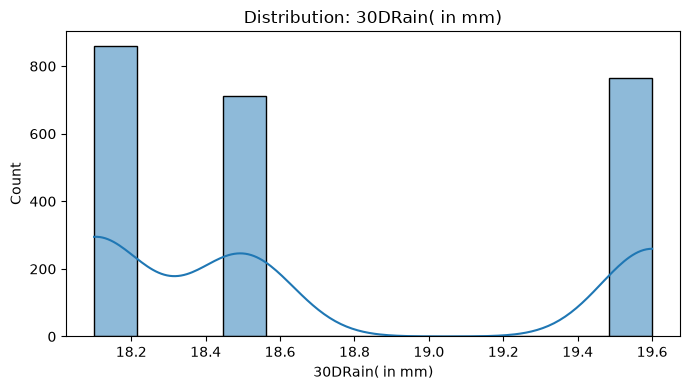

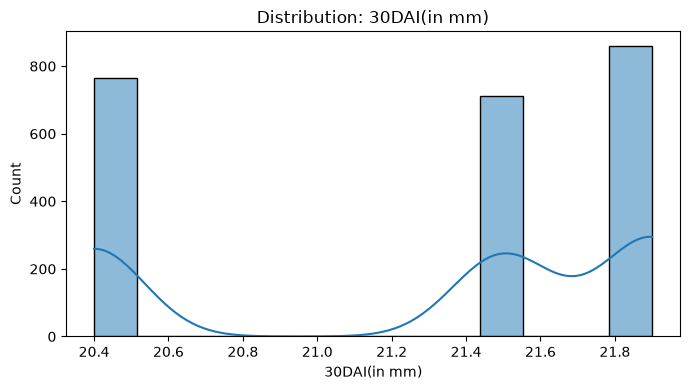

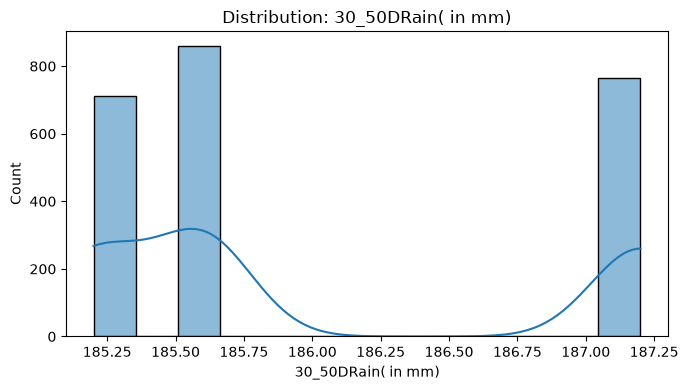

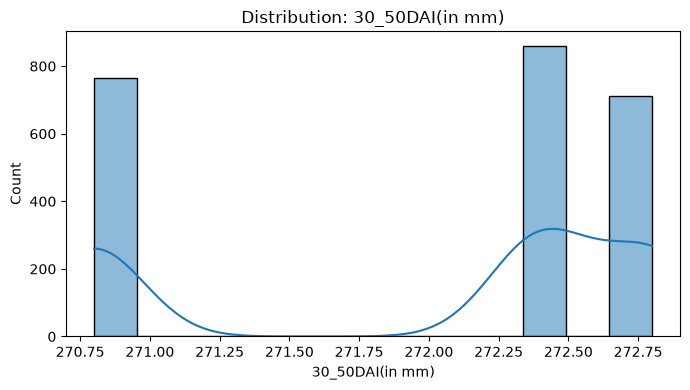

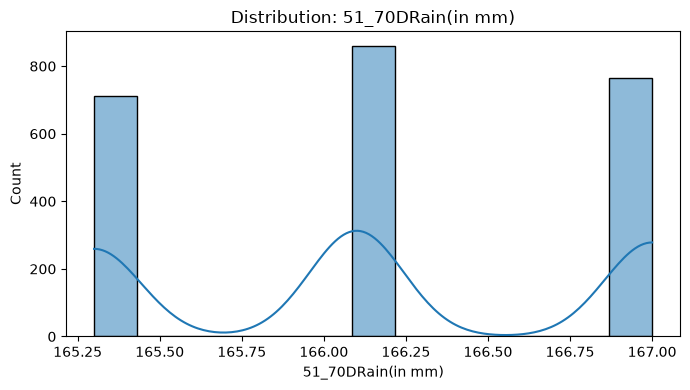

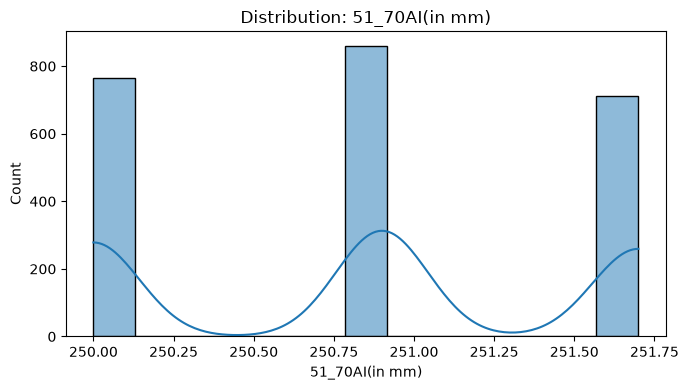

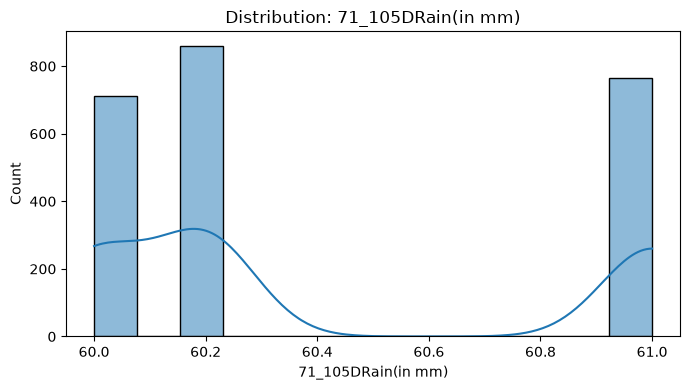

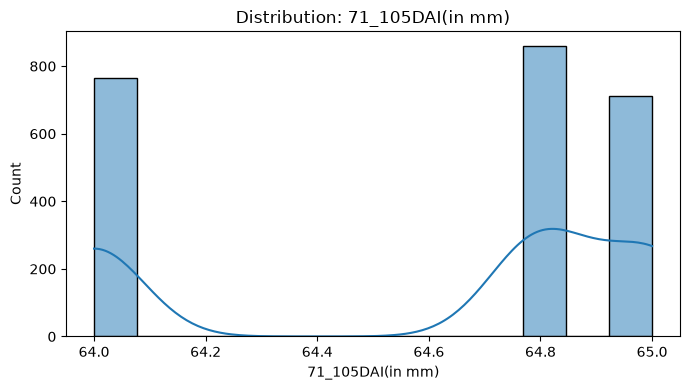

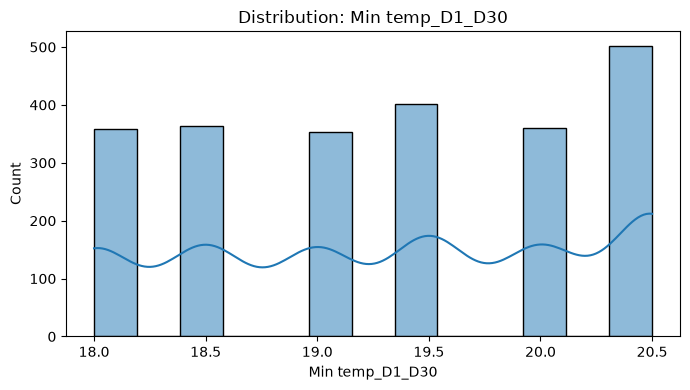

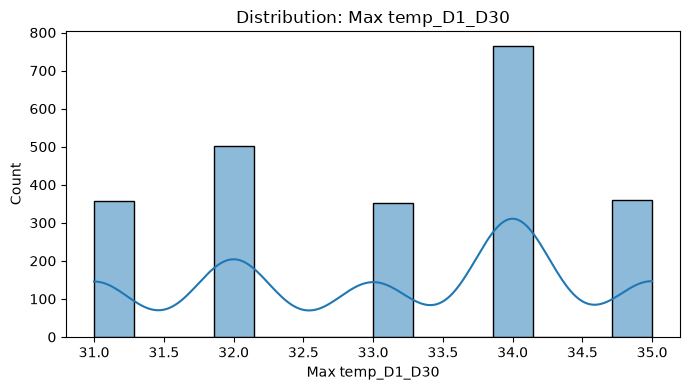

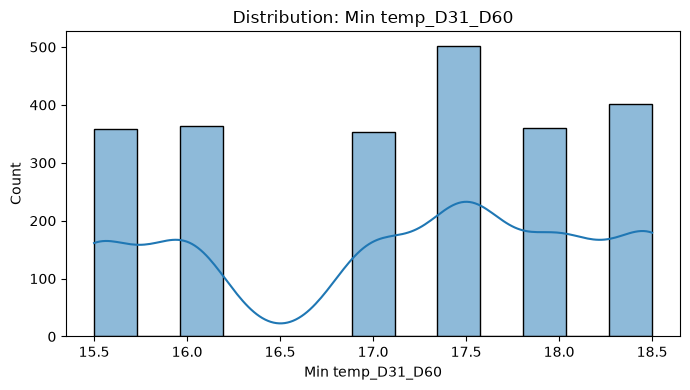

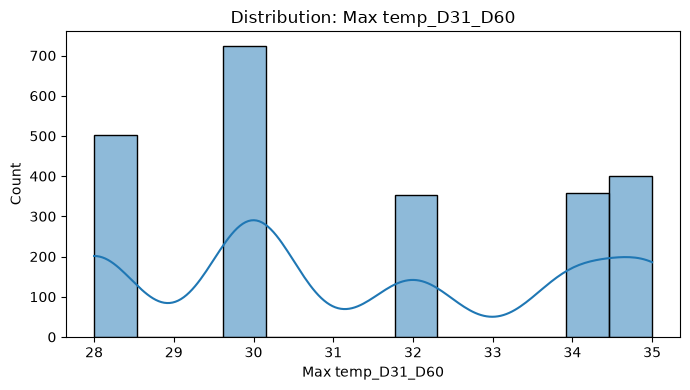

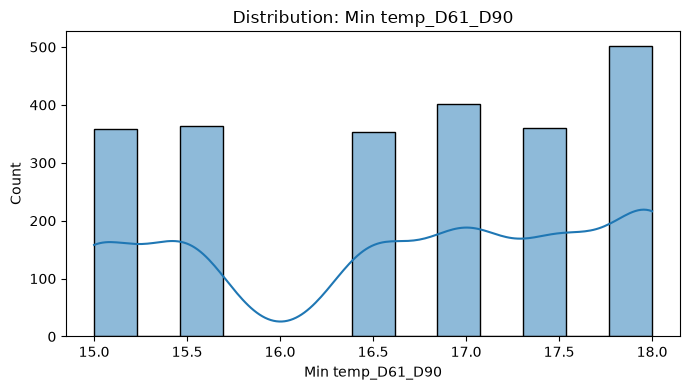

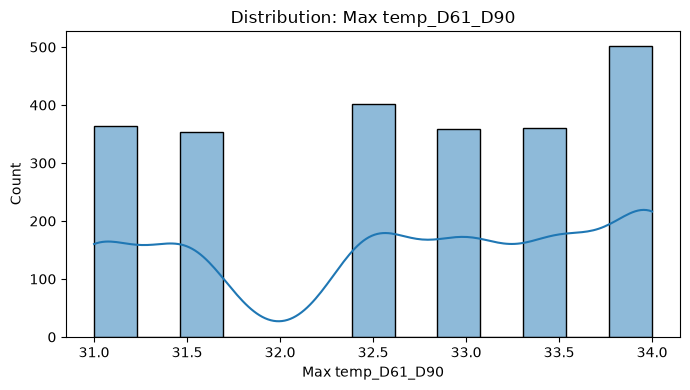

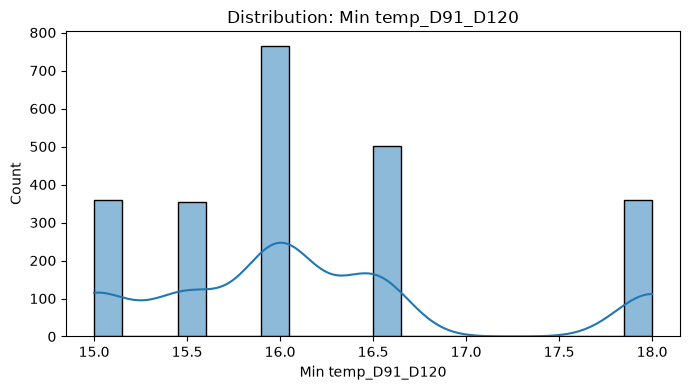

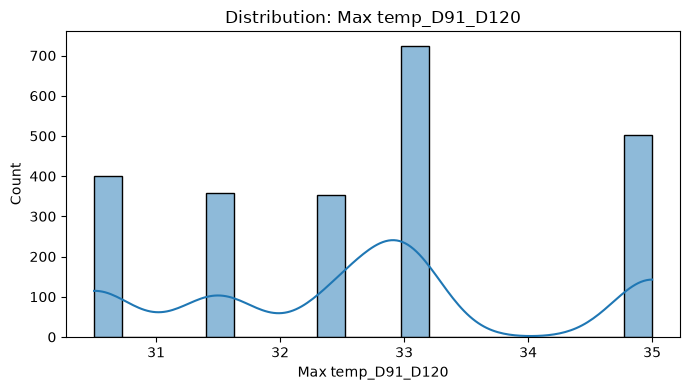

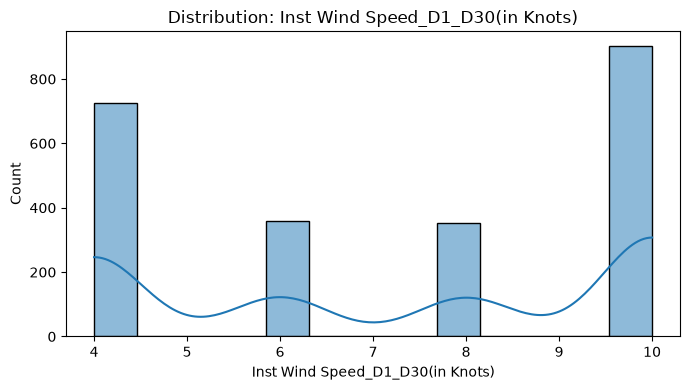

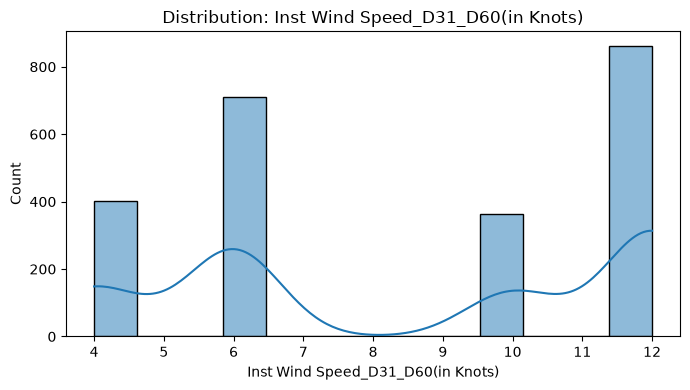

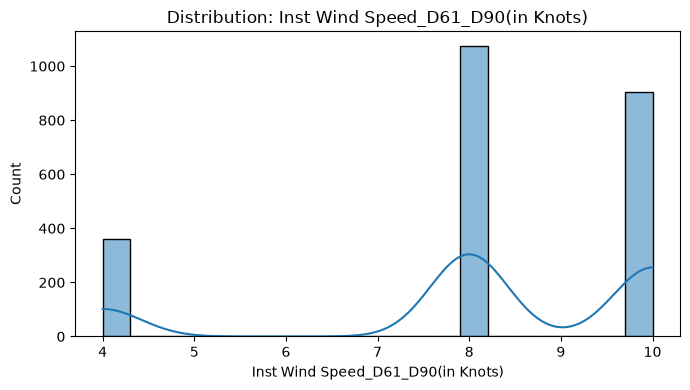

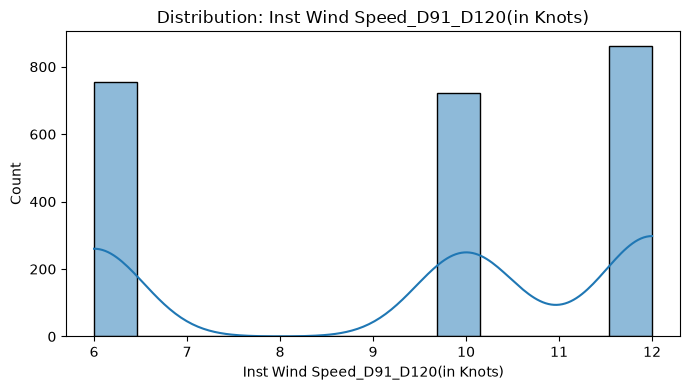

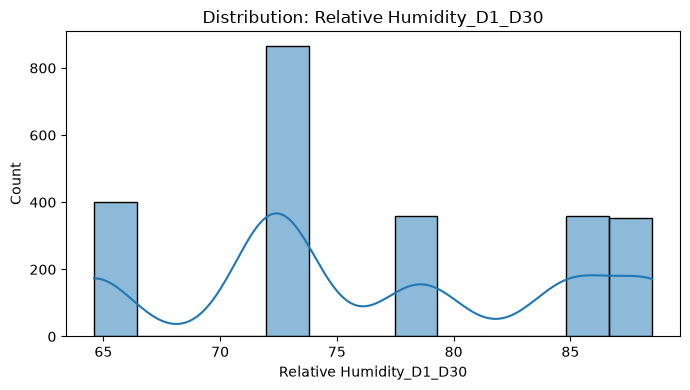

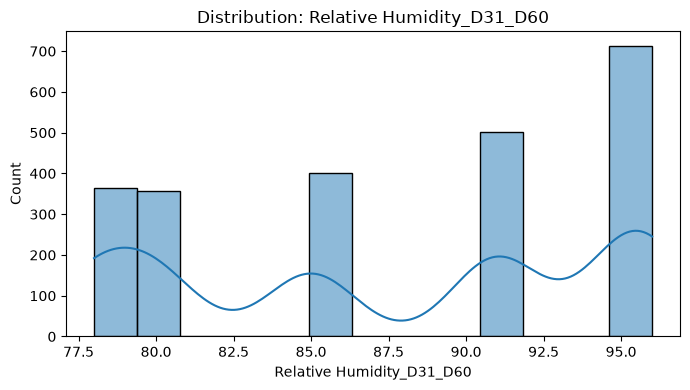

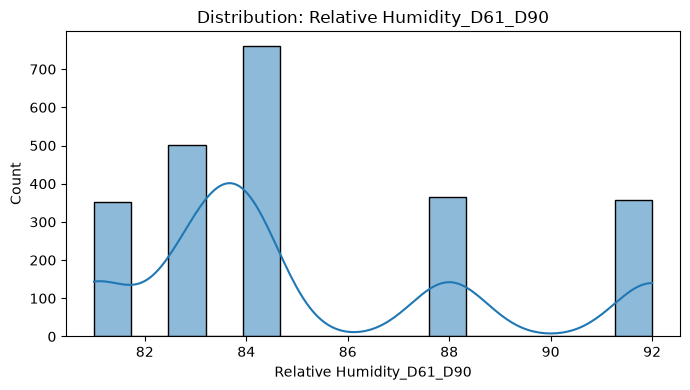

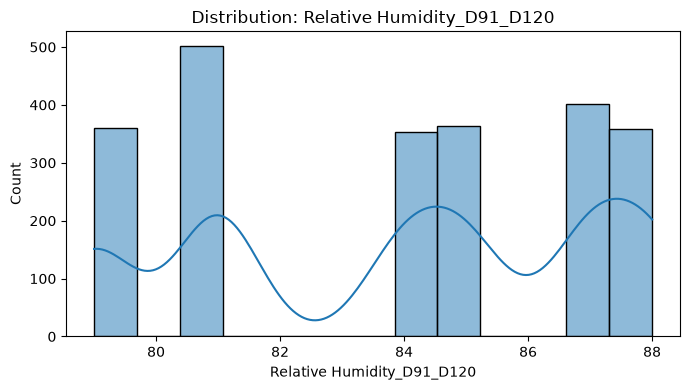

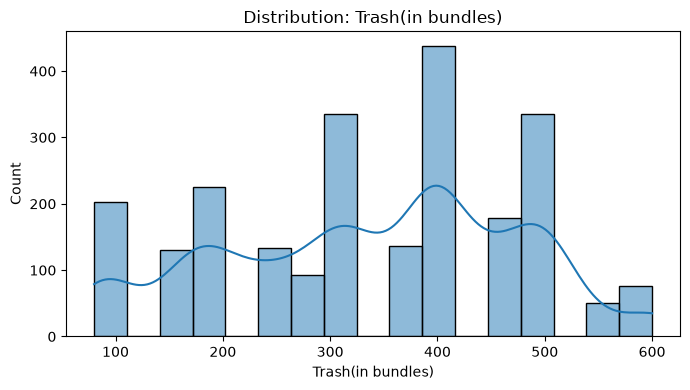

In [27]:
# Numerical feature distributions
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df_model[col], kde=True)
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    plt.show()


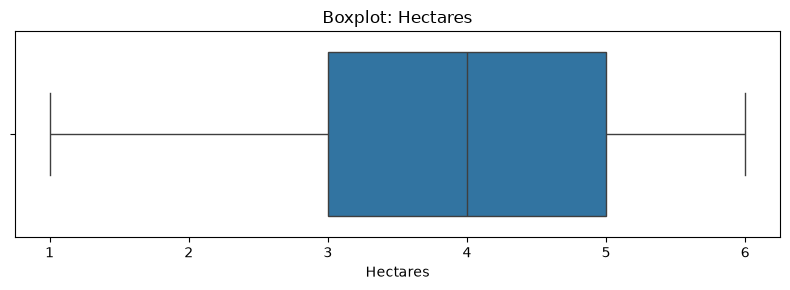

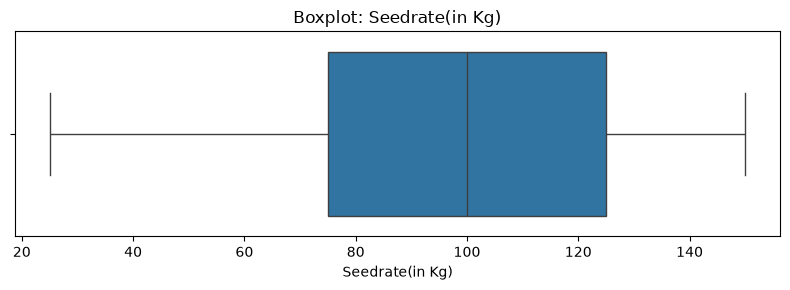

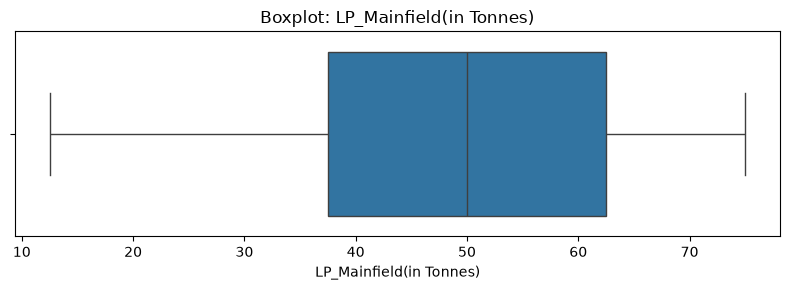

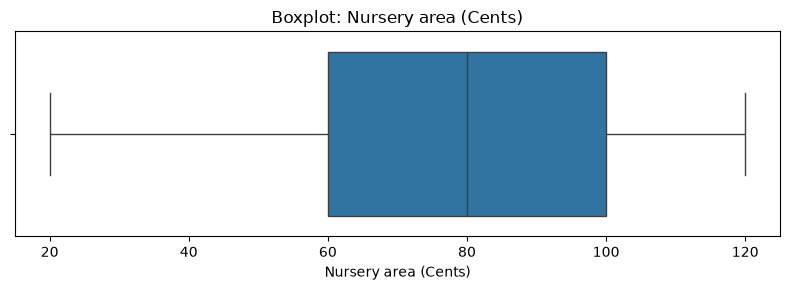

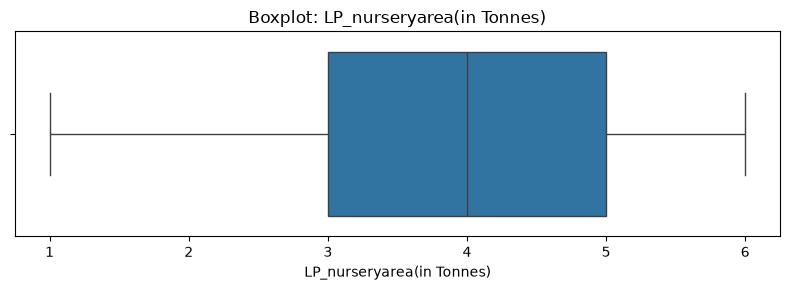

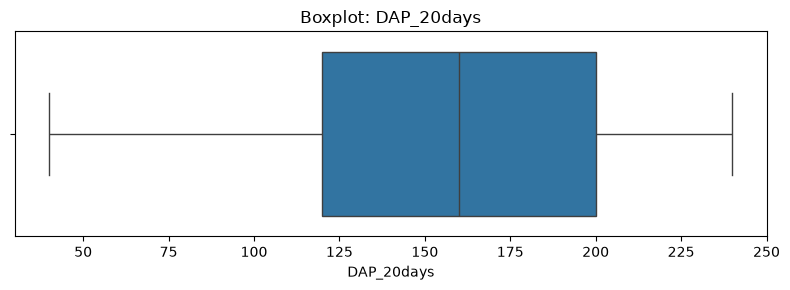

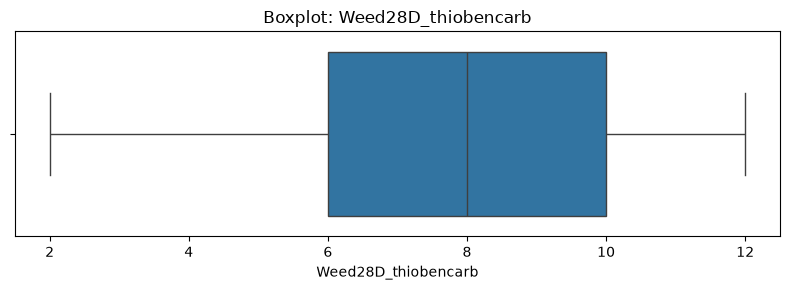

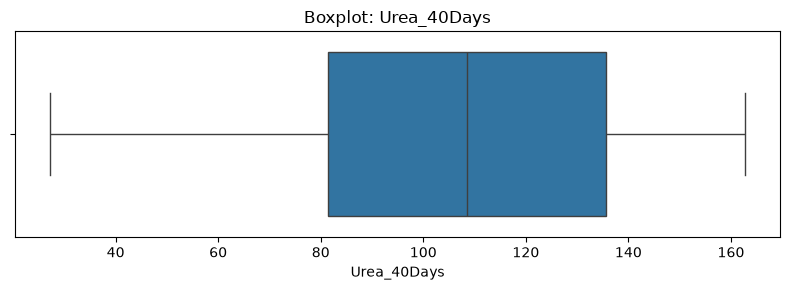

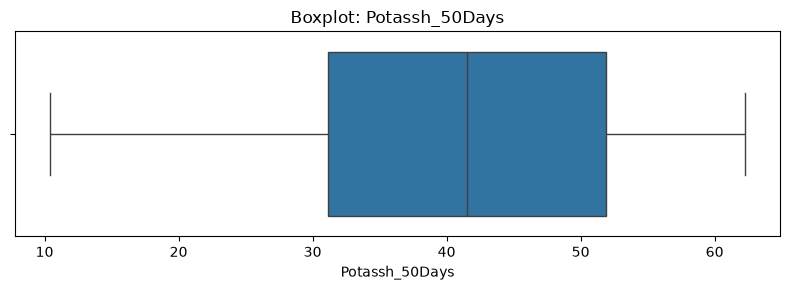

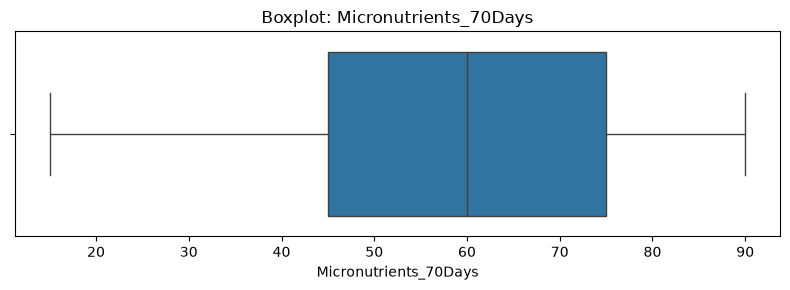

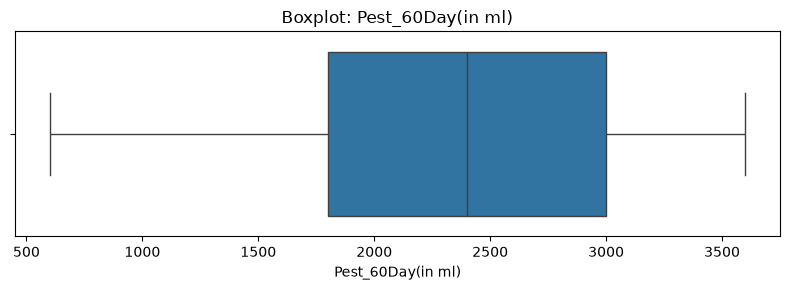

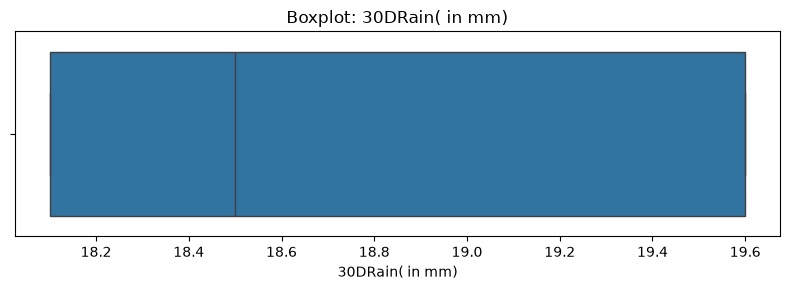

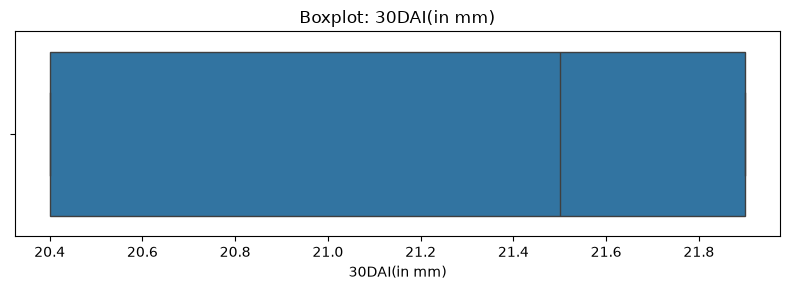

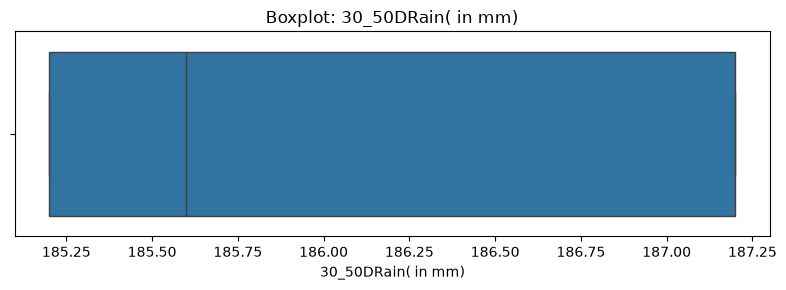

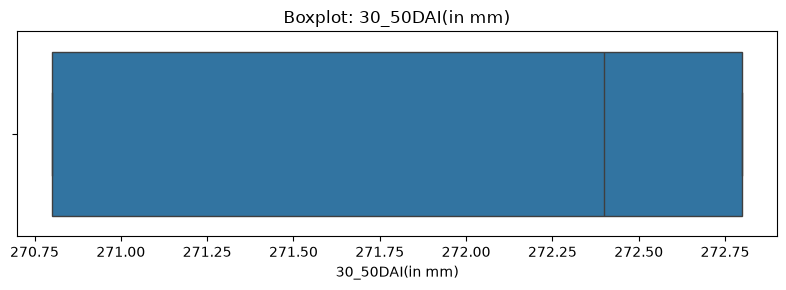

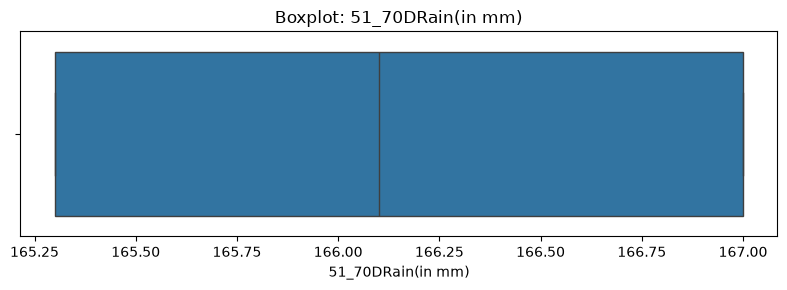

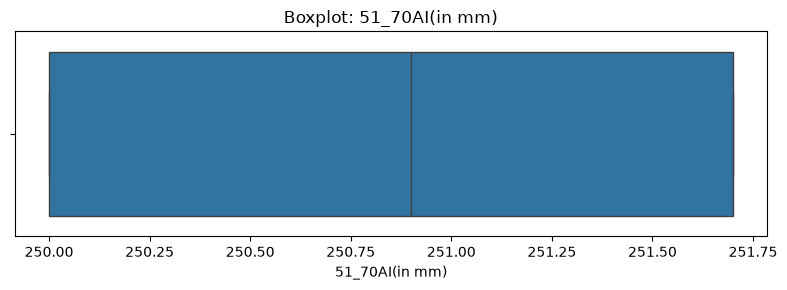

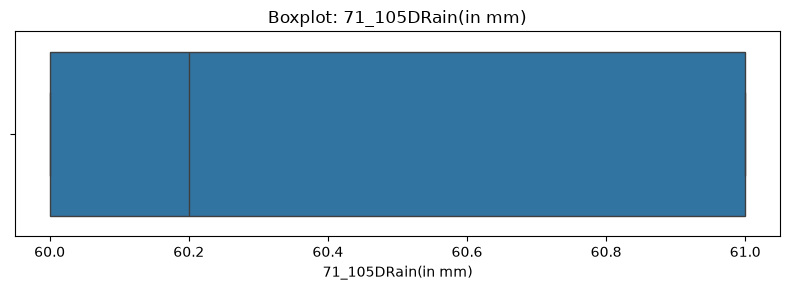

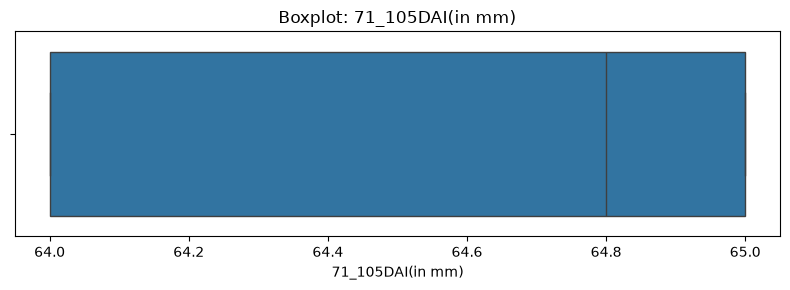

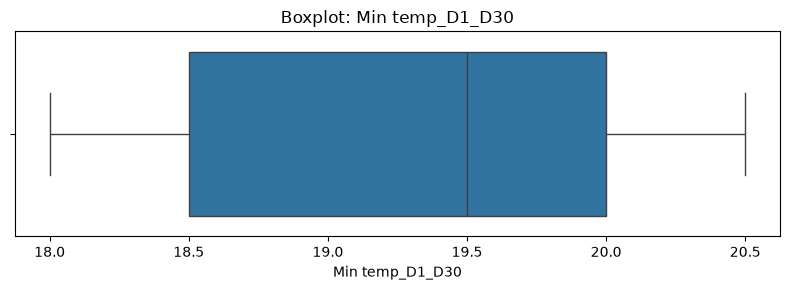

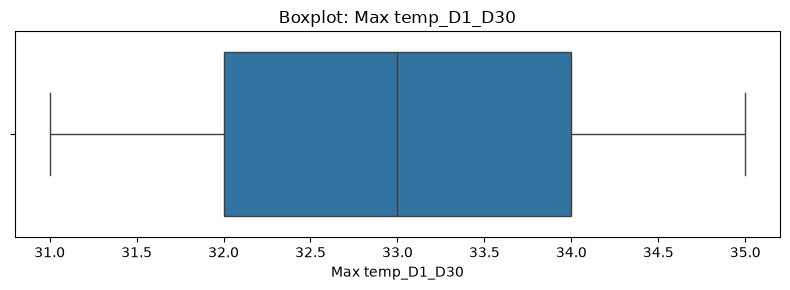

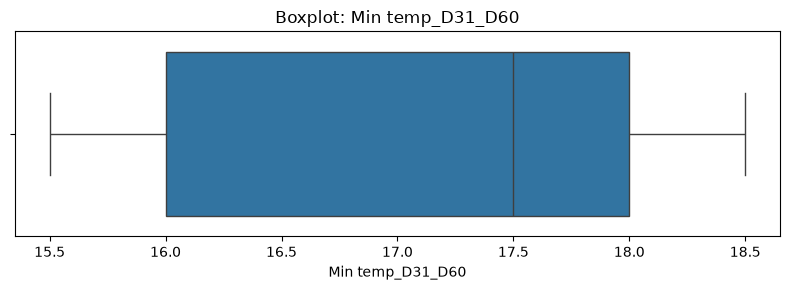

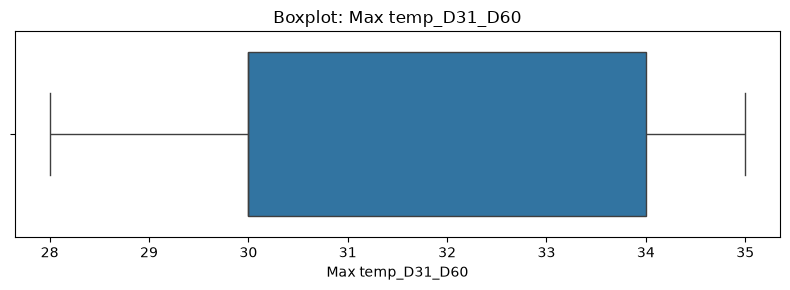

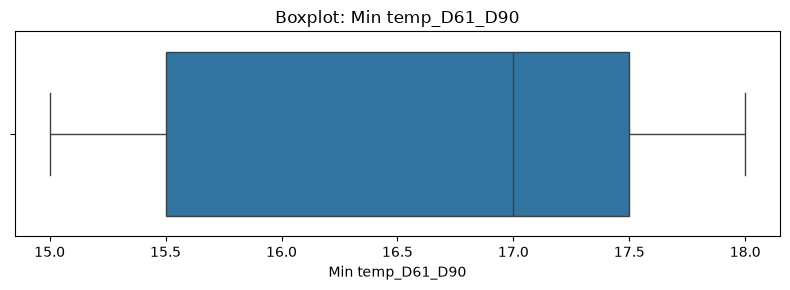

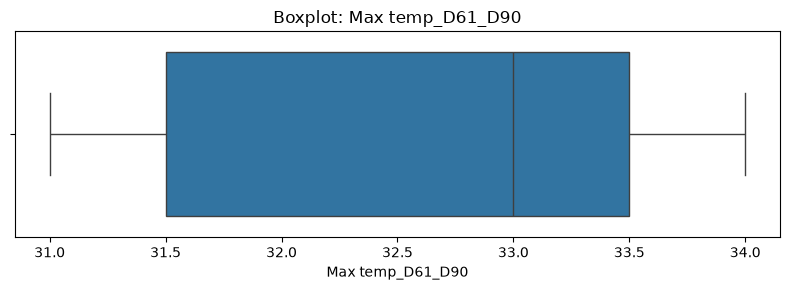

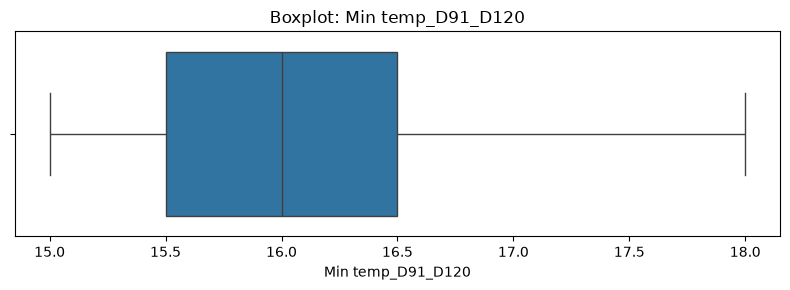

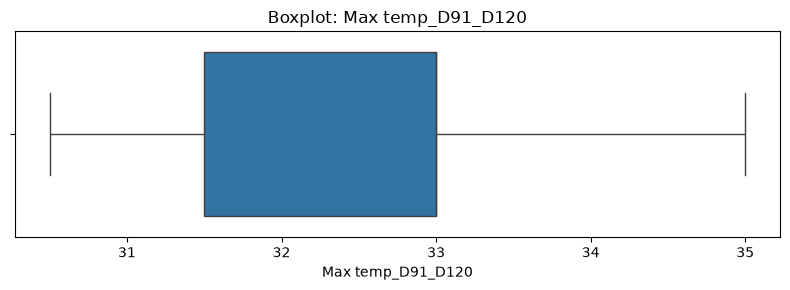

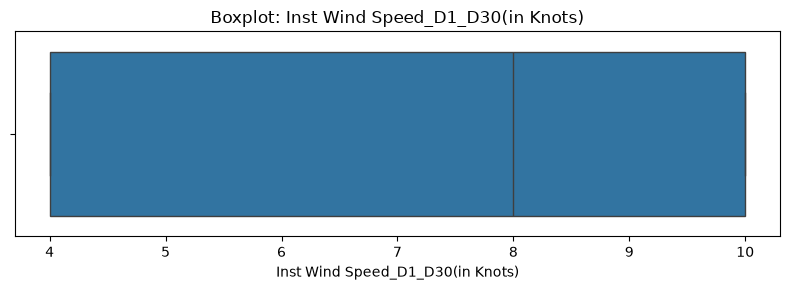

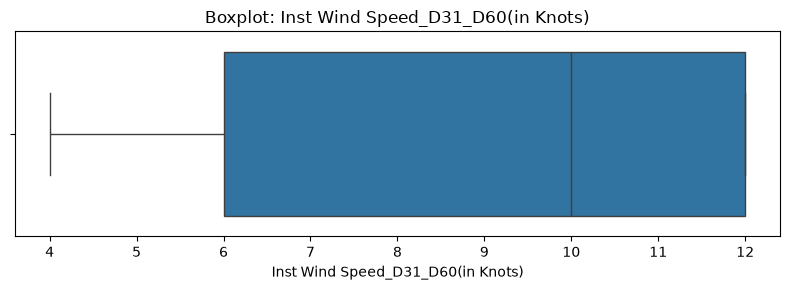

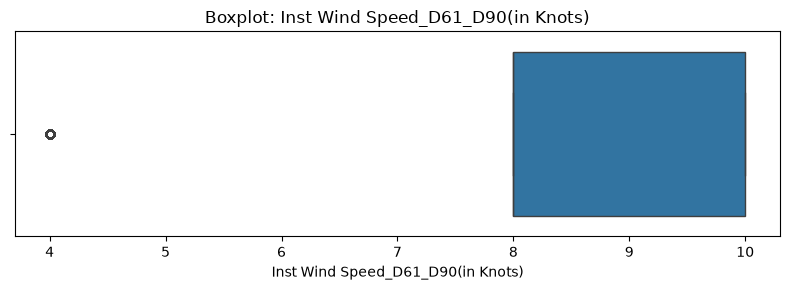

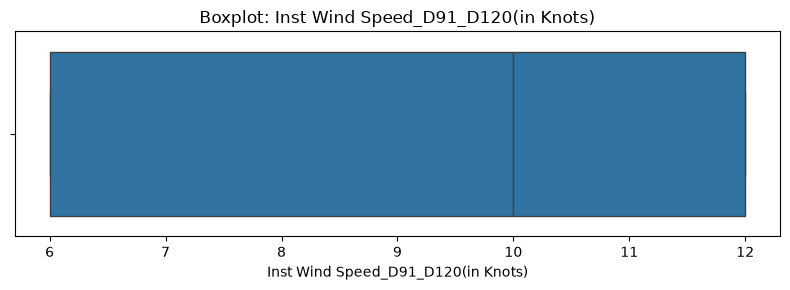

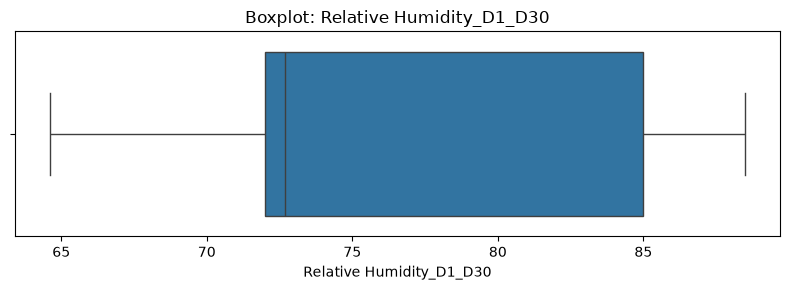

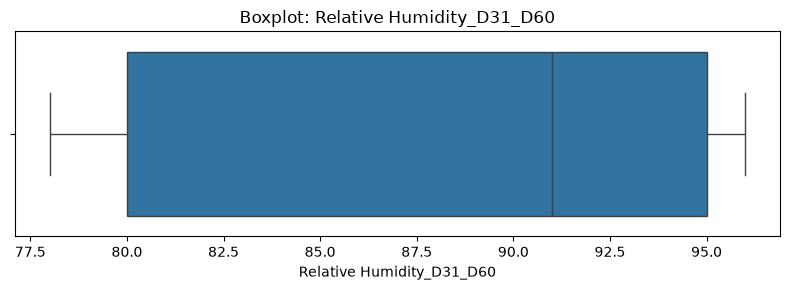

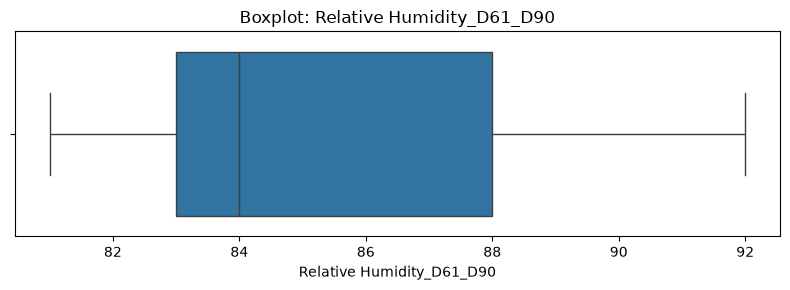

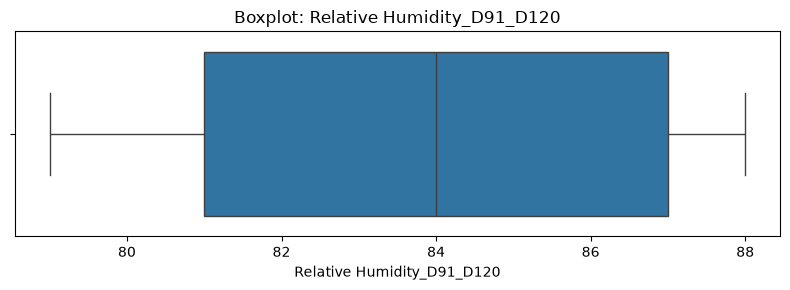

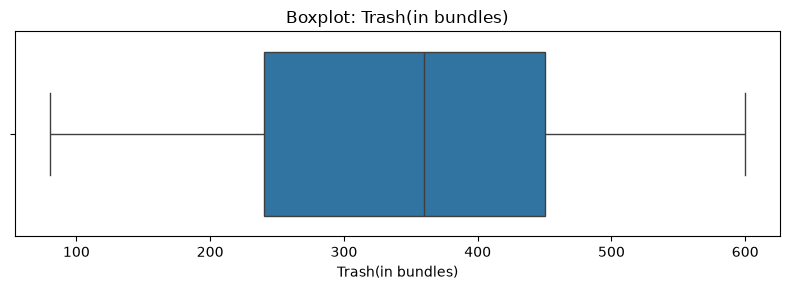

In [28]:
# Outlier inspection
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df_model[col])
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()


In [29]:
# Categorical feature analysis
for col in cat_cols:
    print("\n", col)
    display(df_model[col].value_counts().head(15))



 Agriblock


Agriblock
Sankarapuram    502
Kurinjipadi     401
Cuddalore       364
Panruti         360
Chinnasalem     358
Kallakurichi    353
Name: count, dtype: int64


 Variety


Variety
ponmani        895
delux ponni    832
CO_43          611
Name: count, dtype: int64


 Soil Types


...

Wind Direction_D31_D60
W      866
S      401
NE     360
ENE    358
WNW    353
Name: count, dtype: int64


 Wind Direction_D61_D90


Wind Direction_D61_D90
SE     754
SW     502
NNW    364
NNE    360
NE     358
Name: count, dtype: int64


 Wind Direction_D91_D120


Wind Direction_D91_D120
NW     502
SSE    401
WSW    364
W      360
NNW    358
S      353
Name: count, dtype: int64

,Correlation with Paddy Yield
Paddy yield(in Kg),1.000000
Pest_60Day(in ml),0.994339
Urea_40Days,0.994339
LP_nurseryarea(in Tonnes),0.994339
Hectares,0.994339
Weed28D_thiobencarb,0.994339
Micronutrients_70Days,0.994339
Nursery area (Cents),0.994339
DAP_20days,0.994339
Seedrate(in Kg),0.994339


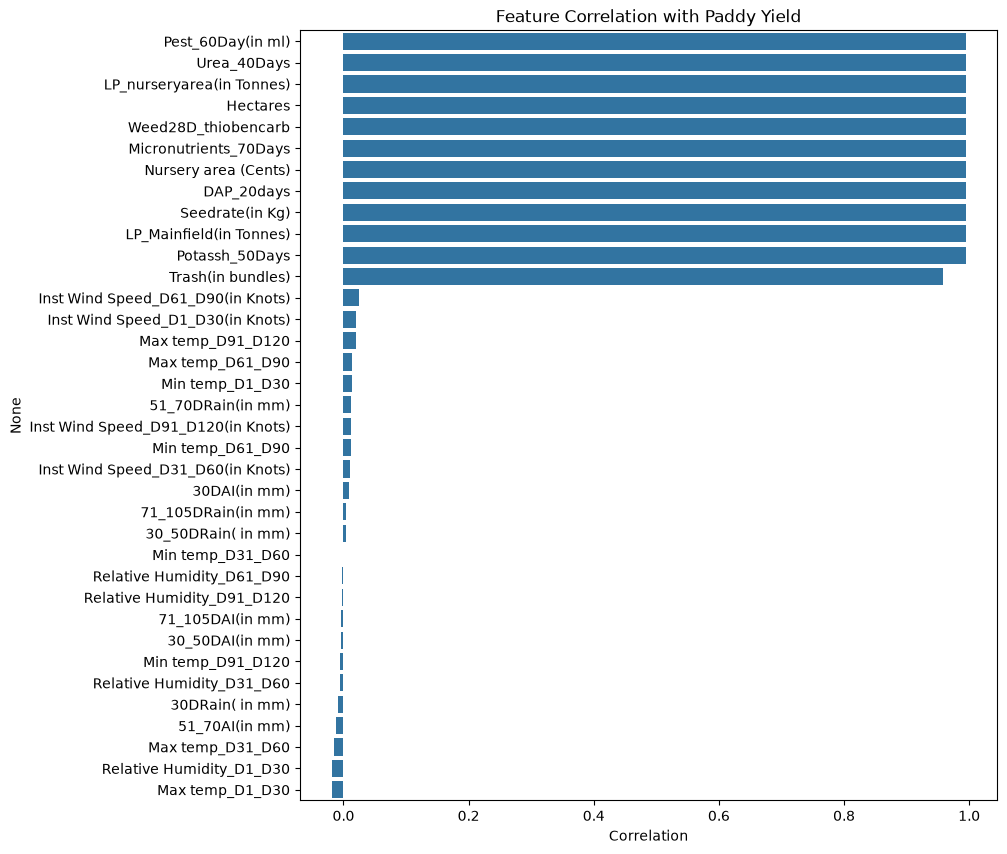

In [30]:
# Correlation with target
corr = df_model[num_cols + [TARGET]].corr(numeric_only=True)[TARGET].sort_values(ascending=False)
display(corr.to_frame("Correlation with Paddy Yield"))

plt.figure(figsize=(9,10))
sns.barplot(x=corr.drop(TARGET).values, y=corr.drop(TARGET).index)
plt.title("Feature Correlation with Paddy Yield")
plt.xlabel("Correlation")
plt.show()


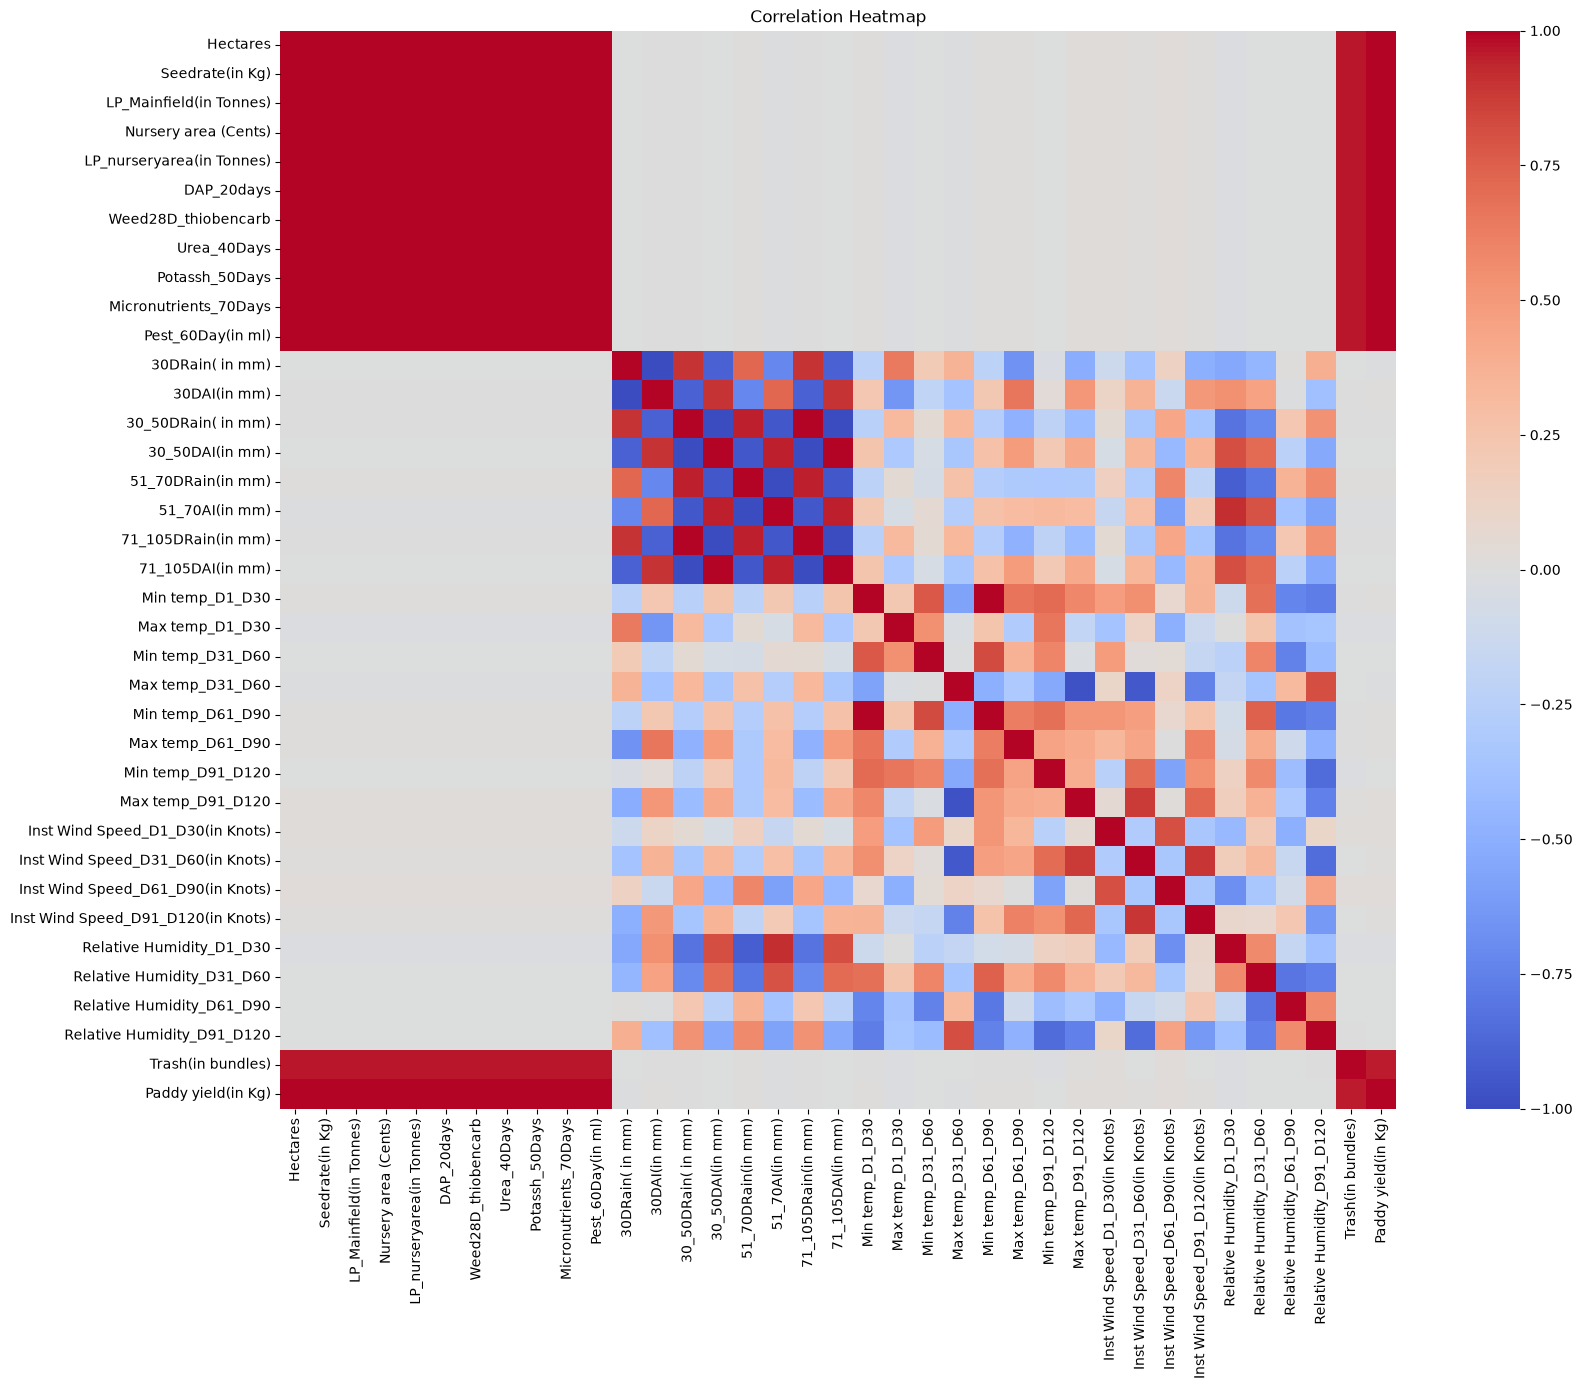

In [31]:
# Correlation heatmap
corr_matrix = df_model[num_cols + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(18,14))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [32]:
# EDA summary
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", duplicate_count)
print("Missing values:", int(df.isna().sum().sum()))
print("Yield mean:", round(df_model[TARGET].mean(), 2))
print("Yield median:", round(df_model[TARGET].median(), 2))
print("Yield min:", round(df_model[TARGET].min(), 2))
print("Yield max:", round(df_model[TARGET].max(), 2))


Rows: 2789
Columns: 45
Duplicate rows: 451
Missing values: 0
Yield mean: 22610.12
Yield median: 24644.0
Yield min: 5410
Yield max: 38814


In [33]:
# Train / test split
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

categorical_cols = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numeric_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Processed training shape:", X_train_processed.shape)


Training rows: 1870
Testing rows: 468
Processed training shape: (1870, 71)


In [34]:
# 1. Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_processed, y_train)

dt_pred = dt_model.predict(X_test_processed)
dt_r2 = r2_score(y_test, dt_pred)
dt_rmse = mean_squared_error(y_test, dt_pred) ** 0.5

print("Decision Tree")
print("R2:", dt_r2)
print("RMSE:", dt_rmse)


Decision Tree
R2: 0.9887884783068401
RMSE: 979.7029551985433


In [35]:
# 2. Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)
rf_pred = rf_model.predict(X_test_processed)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5

print("Random Forest")
print("R2:", rf_r2)
print("RMSE:", rf_rmse)


Random Forest
R2: 0.9890421070960838
RMSE: 968.5580679037914


In [36]:
# 3. Support Vector Regression
scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)

svr_pred = svr_model.predict(X_test_scaled)

svr_r2 = r2_score(y_test, svr_pred)
svr_rmse = mean_squared_error(y_test, svr_pred) ** 0.5

print("SVR")
print("R2:", svr_r2)
print("RMSE:", svr_rmse)


SVR
R2: -0.034454090409499205
RMSE: 9410.609401616148


In [37]:
# Model comparison
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "SVR"],
    "R2": [dt_r2, rf_r2, svr_r2],
    "RMSE": [dt_rmse, rf_rmse, svr_rmse]
}).sort_values("R2", ascending=False)

display(results)


,Model,R2,RMSE
1,Random Forest,0.989042,968.558068
0,Decision Tree,0.988788,979.702955
2,SVR,-0.034454,9410.609402


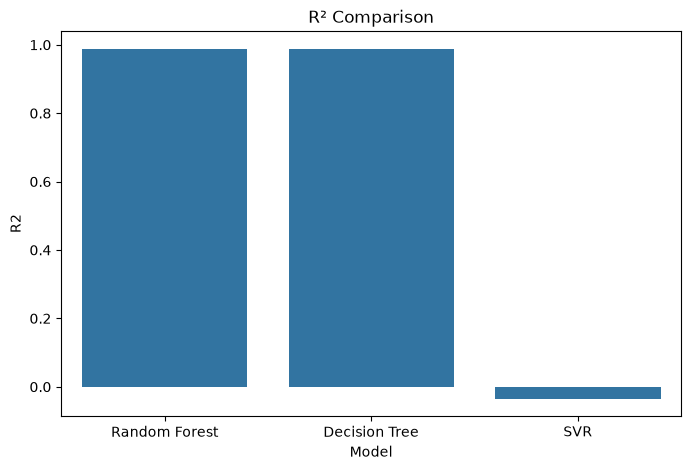

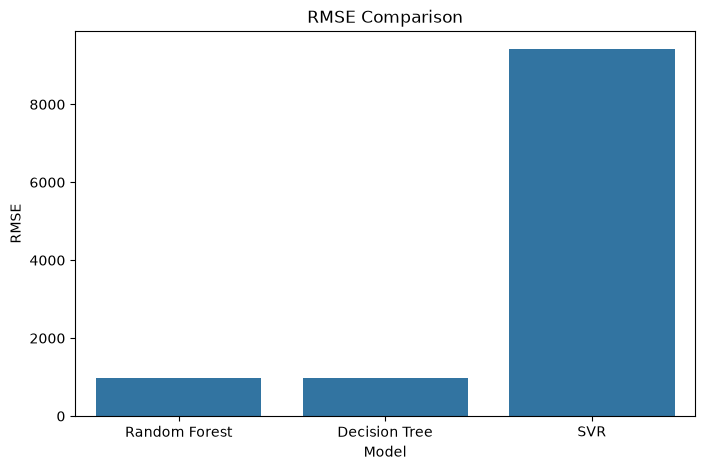

In [38]:
# Visual comparison
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="R2")
plt.title("R² Comparison")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="RMSE")
plt.title("RMSE Comparison")
plt.show()


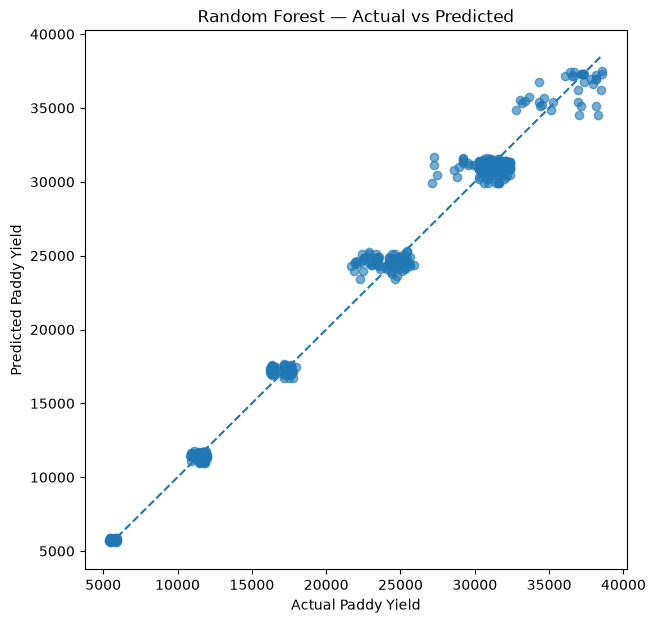

In [39]:
# Best model: Random Forest
plt.figure(figsize=(7,7))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.xlabel("Actual Paddy Yield")
plt.ylabel("Predicted Paddy Yield")
plt.title("Random Forest — Actual vs Predicted")

low = min(y_test.min(), rf_pred.min())
high = max(y_test.max(), rf_pred.max())
plt.plot([low, high], [low, high], linestyle="--")
plt.show()


In [41]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("random_forest_model.pkl saved")

random_forest_model.pkl saved


In [42]:
# Save the best model and preprocessing pipeline
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("random_forest_model.pkl saved")
print("preprocessor.pkl saved")


random_forest_model.pkl saved
preprocessor.pkl saved


In [43]:
# Final prediction test
loaded_model = joblib.load("random_forest_model.pkl")
loaded_preprocessor = joblib.load("preprocessor.pkl")

sample = X_test.iloc[[0]]
sample_processed = loaded_preprocessor.transform(sample)
prediction = loaded_model.predict(sample_processed)[0]

print("Actual yield:", y_test.iloc[0], "Kg")
print("Predicted yield:", round(prediction, 2), "Kg")


Actual yield: 31555 Kg
Predicted yield: 30470.63 Kg
